# P3 - Building Blocks: Full-Network Temporal Adjacency

This notebook demonstrates one of the building blocks used in the P3 pipeline:
the construction of **per-timestep adjacency matrices** over the entire WSN —
sink, candidate relays, and mobile sensors — plus the **accumulated
co-occurrence matrix** `A_total = sum_t A(t)`.

Module under test: [`adjacency_builder.py`](adjacency_builder.py).

## Layout (1 + N + M)

Every matrix `A(t)` is square of shape `(K, K)` with

$$K = 1 + N + M,$$

where `N` is the number of candidate relays and `M` is the number of mobile
sensors. Both axes share the same canonical ordering:

| index range       | role                                           |
| ----------------- | ---------------------------------------------- |
| `0`               | sink                                           |
| `1 .. N`          | candidate relays (order of `problem.candidates`) |
| `N+1 .. N+M`      | mobile sensors (order of `problem.mobile_nodes`) |

For each timestep `t` and each pair `(u, v)`:

$$A(t)[u, v] = 1 \iff u \neq v \ \text{and}\ \| \text{pos}_u(t) - \text{pos}_v(t) \| \leq R.$$

Distance is Euclidean 2D. The matrix is symmetric with zero diagonal. The
sink and candidate sub-blocks are constant across time; only the mobile rows
and columns vary.

## Load an instance and run the pipeline

In [60]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import adjacency_builder as ab
importlib.reload(ab)  # pick up edits to the module without restarting the kernel

INSTANCE_PATH = "pop-estimator/examples/ind2.json"

instance = ab.load_instance(INSTANCE_PATH)
result   = ab.build_from_instance(instance)
summary  = ab.summarise(result, instance)
ab.print_summary(summary)

Instance:           C:\Users\jcf_s\source\git\simlab-algorithms\pop-estimator\examples\ind2.json
Radius of reach:    50.0
Timesteps (T):      181
Nodes (K=1+N+M):    69  (N=64, M=4)
Raw step counts:    [181, 90, 48, 120]  (T = max)
Tensor shape:       (181, 69, 69)  (T, K, K), uint8 symmetric, zero diag
Accumulated shape:  (69, 69)  (K, K), int64
Accumulated A_total stats:
  min = 0, max = 181, mean = 13.232, sum = 62996, density = 11.80%
Per-block A_total density (% of pairs ever in range):
  sink <-> cand   min=   0  max= 181  mean=  19.80  density= 10.94%
  sink <-> mob    min=   0  max=  15  mean=   3.75  density= 25.00%
  cand <-> cand   min=   0  max= 181  mean=  12.64  density=  6.98%
  cand <-> mob    min=   0  max= 172  mean=  16.36  density= 49.22%
  mob  <-> mob    min=   0  max=  70  mean=  18.00  density= 50.00%
Per-timestep density (fraction of pairs in range):
  min = 7.02%, max = 7.56%, mean = 7.31%


## Inspect tensor, accumulated matrix, and layout

* `tensor`      has shape `(T, K, K)` — one symmetric, zero-diagonal
  binary matrix per timestep.
* `accumulated` has shape `(K, K)` — number of timesteps each pair stayed
  within range. Static sub-blocks (sink ↔ candidates, candidate ↔ candidate)
  are either `0` or `T`.
* `layout` describes the canonical `[sink | candidates | mobiles]` ordering.

In [61]:
positions   = result["positions"]     # (T, K, 2)
tensor      = result["tensor"]        # (T, K, K), uint8
accumulated = result["accumulated"]   # (K, K),    int64
layout      = result["layout"]
R           = result["radius"]

T, K, _ = tensor.shape
N, M    = layout.N, layout.M
s_idx   = layout.sink_index
c_idx   = np.asarray(layout.candidate_indices)
m_idx   = np.asarray(layout.mobile_indices)

print(f"tensor:      shape={tensor.shape}, dtype={tensor.dtype}")
print(f"accumulated: shape={accumulated.shape}, dtype={accumulated.dtype}")
print(f"positions:   shape={positions.shape}, dtype={positions.dtype}")
print(f"K = 1 + N + M = 1 + {N} + {M} = {K}")
print(f"radius R = {R}, horizon T = {T}")

# Sanity: symmetric, zero diagonal
assert np.array_equal(tensor, tensor.transpose(0, 2, 1)), "tensor must be symmetric per t"
assert (tensor.diagonal(axis1=1, axis2=2) == 0).all(), "diagonal must be zero"
assert np.array_equal(accumulated, accumulated.T), "accumulated must be symmetric"

tensor:      shape=(181, 69, 69), dtype=uint8
accumulated: shape=(69, 69), dtype=int64
positions:   shape=(181, 69, 2), dtype=float64
K = 1 + N + M = 1 + 64 + 4 = 69
radius R = 50.0, horizon T = 181


## Heatmap of the accumulated co-occurrence matrix

We draw thin separators between the three blocks `[sink | candidates | mobiles]`
to make the layout obvious. Each cell counts how many timesteps the two
corresponding nodes stayed within `R` of each other.

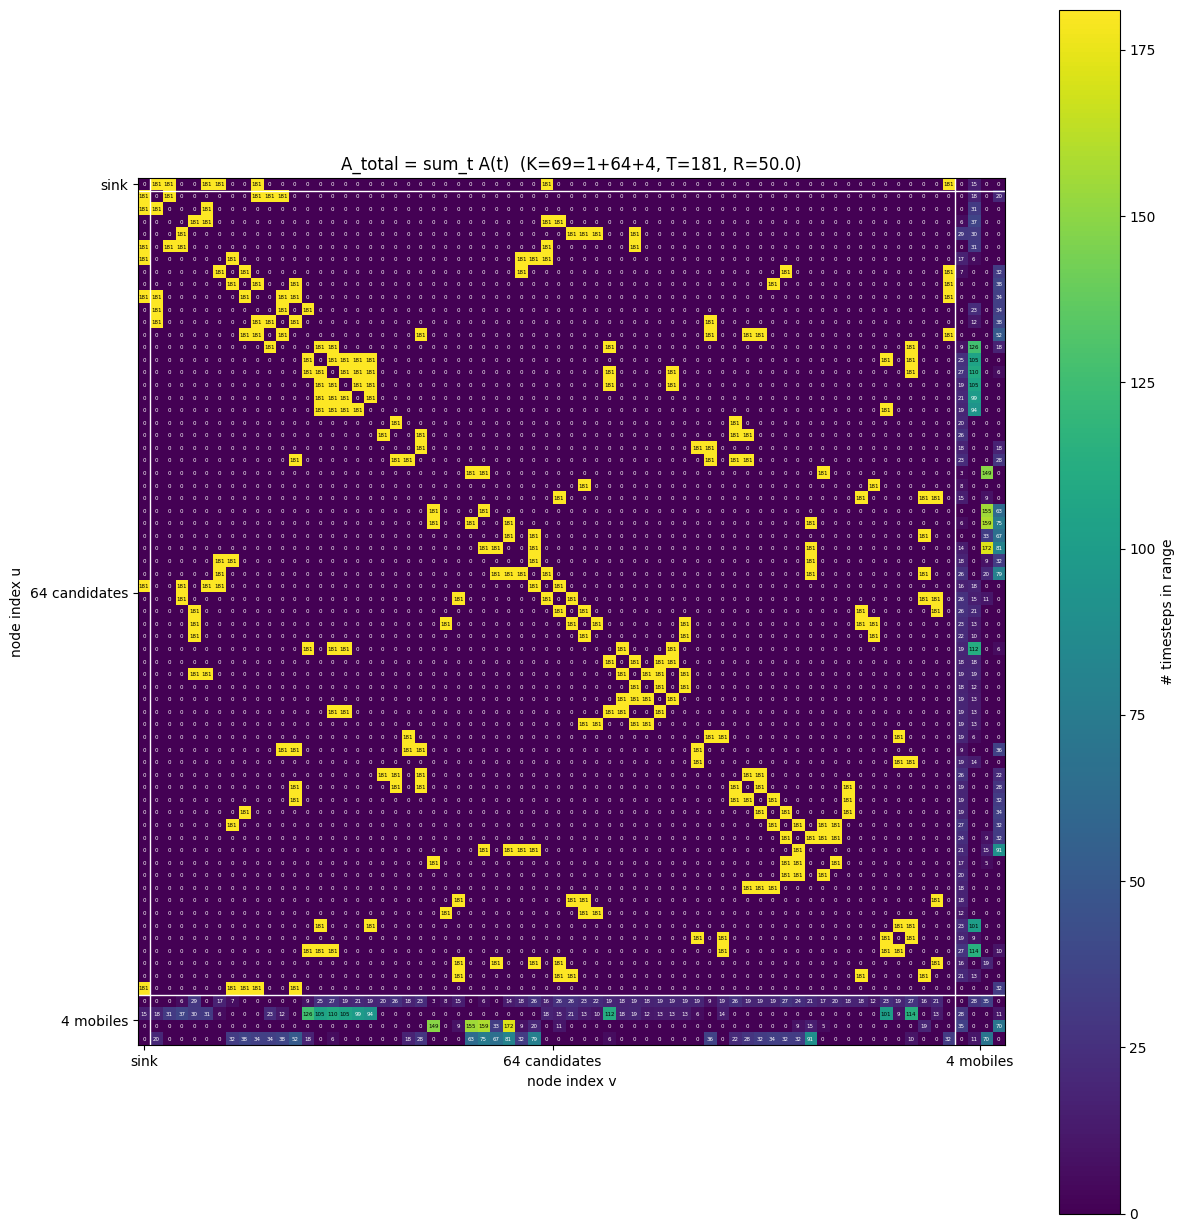

In [62]:
fig, ax = plt.subplots(figsize=(max(8.5, 0.18 * K), max(7.5, 0.18 * K)))
im = ax.imshow(accumulated, cmap="viridis")
ax.set_xlabel("node index v")
ax.set_ylabel("node index u")
ax.set_title(
    f"A_total = sum_t A(t)  (K={K}=1+{N}+{M}, T={T}, R={R})"
)

# Per-cell number annotations. Text colour flips for readability against the
# colormap (white on dark cells, black on bright cells).
vmax = max(int(accumulated.max()), 1)
threshold = vmax * 0.55
font_size = max(4, min(9, int(160 / K)))
for u in range(K):
    for v in range(K):
        val = int(accumulated[u, v])
        ax.text(v, u, str(val),
                ha="center", va="center",
                fontsize=font_size,
                color="white" if val < threshold else "black")

# Block separators after sink (index 0) and after candidates (index N)
for split in (0.5, 0.5 + N):
    ax.axhline(split, color="white", linewidth=1.0)
    ax.axvline(split, color="white", linewidth=1.0)
# Axis labels at the centre of each block
centres = [0, 0.5 + N / 2.0, 0.5 + N + M / 2.0]
ax.set_xticks(centres); ax.set_xticklabels(["sink", f"{N} candidates", f"{M} mobiles"])
ax.set_yticks(centres); ax.set_yticklabels(["sink", f"{N} candidates", f"{M} mobiles"])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("# timesteps in range")
plt.tight_layout()
plt.show()

## Per-timestep density and per-mobile degree

Density at time `t` is the fraction of off-diagonal pairs in range. The
lower panel plots, for each mobile sensor, how many other nodes (sink and
candidates and other mobiles) are in range over time — useful for spotting
coverage gaps.

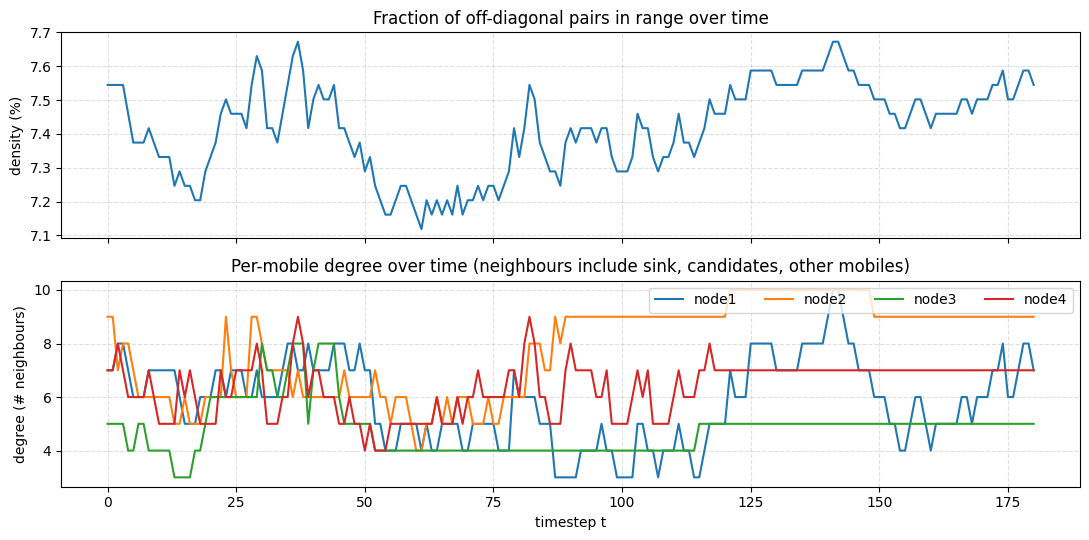

In [63]:
off_diag_pairs = K * (K - 1)  # symmetric, but density is computed over the full off-diagonal
density_per_t = tensor.sum(axis=(1, 2)) / off_diag_pairs

# Per-mobile degree over time = row sums for mobile rows (each mobile sees
# the sink + candidates + the other M-1 mobiles)
mobile_degree_t = tensor[:, m_idx, :].sum(axis=2)  # (T, M)

fig, (ax_d, ax_s) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax_d.plot(density_per_t * 100.0, color="tab:blue")
ax_d.set_ylabel("density (%)")
ax_d.set_title("Fraction of off-diagonal pairs in range over time")
ax_d.grid(True, linestyle="--", alpha=0.4)

for i, m in enumerate(instance.mobile_nodes):
    ax_s.plot(mobile_degree_t[:, i], label=m.name)
ax_s.set_ylabel("degree (# neighbours)")
ax_s.set_xlabel("timestep t")
ax_s.set_title("Per-mobile degree over time (neighbours include sink, candidates, other mobiles)")
ax_s.grid(True, linestyle="--", alpha=0.4)
ax_s.legend(loc="upper right", ncols=min(M, 4))
plt.tight_layout()
plt.show()

## Block-level sanity

Because sink and candidate positions are static, the corresponding cells in
`A_total` must be either `0` or `T`. Mobile rows/columns may take any value
in `0..T`.

In [64]:
static_idx = np.r_[s_idx, c_idx]
static_block = accumulated[np.ix_(static_idx, static_idx)]
is_static_zero_or_T = np.isin(static_block, [0, T]).all()
print(f"static (sink+cand) sub-block values are all 0 or T: {is_static_zero_or_T}")
print(f"# static edges (cells == T) per row: min={int((static_block == T).sum(axis=1).min())}, "
      f"max={int((static_block == T).sum(axis=1).max())}")
print(f"mobile sub-block A_total range: "
      f"[{accumulated[np.ix_(m_idx, m_idx)].min()}, "
      f"{accumulated[np.ix_(m_idx, m_idx)].max()}]")

static (sink+cand) sub-block values are all 0 or T: True
# static edges (cells == T) per row: min=2, max=8
mobile sub-block A_total range: [0, 70]


## Per-fixed-node score

Each fixed node (sink + candidates) gets a single score derived from `A_total`:

$$\text{score}(u) = \sum_{m \in \text{mobiles}} A_{\text{total}}[u, m]$$

i.e. the **total number of mobile-timesteps** during which the fixed node was
within `R` of some mobile sensor. High score = candidate that frequently covers
mobile traffic over the simulation horizon. A candidate with score `0` is never
in range of any mobile and can be safely pruned from the search space.

Maximum possible score = T * M = 724  (each fixed node, in range of every mobile at every t)
Score range observed   = [8, 267]
Fixed nodes with score 0 (never cover any mobile): 0 / 65


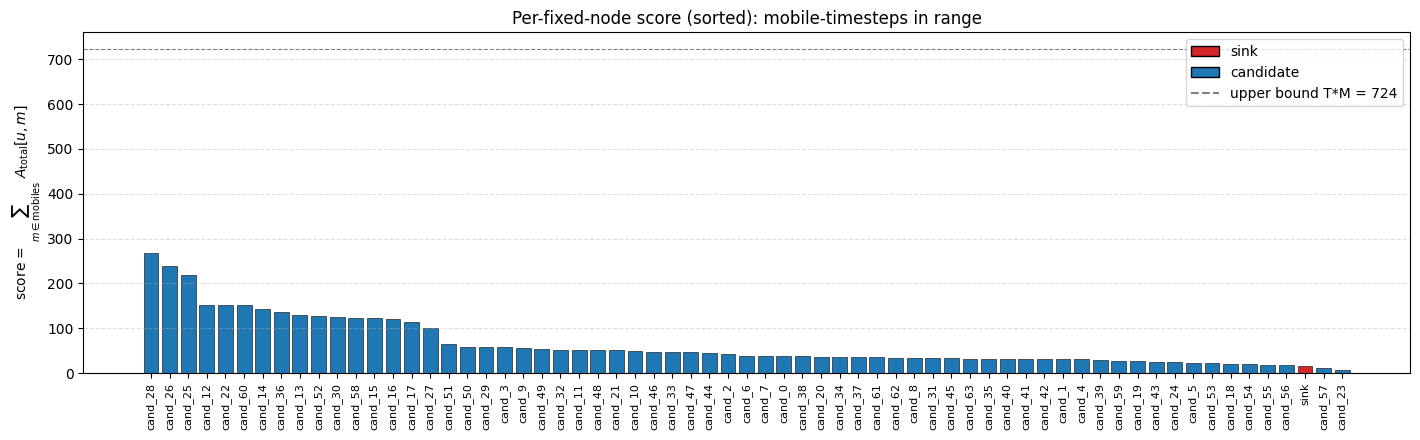

In [65]:
fixed_idx   = np.r_[s_idx, c_idx]                                # length 1+N
fixed_names = [layout.names[i] for i in fixed_idx]
scores      = accumulated[np.ix_(fixed_idx, m_idx)].sum(axis=1)  # length 1+N

order      = np.argsort(scores)[::-1]
sorted_scores = scores[order]
sorted_names  = [fixed_names[i] for i in order]
sorted_kind   = ["sink" if fixed_idx[i] == s_idx else "candidate" for i in order]
colors        = ["tab:red" if k == "sink" else "tab:blue" for k in sorted_kind]

print(f"Maximum possible score = T * M = {T * M}  (each fixed node, in range of every mobile at every t)")
print(f"Score range observed   = [{int(scores.min())}, {int(scores.max())}]")
print(f"Fixed nodes with score 0 (never cover any mobile): "
      f"{int((scores == 0).sum())} / {len(scores)}")

fig, ax = plt.subplots(figsize=(max(9, 0.22 * len(scores)), 4.5))
ax.bar(range(len(scores)), sorted_scores, color=colors, edgecolor="black", linewidth=0.4)
ax.set_xticks(range(len(scores)))
ax.set_xticklabels(sorted_names, rotation=90, fontsize=8)
ax.axhline(T * M, color="gray", linestyle="--", linewidth=0.8,
           label=f"upper bound T*M = {T * M}")
ax.set_ylabel("score = $\\sum_{m \\in \\mathrm{mobiles}}$ $A_{\\mathrm{total}}[u, m]$")
ax.set_title("Per-fixed-node score (sorted): mobile-timesteps in range")
# legend with one entry per kind
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="tab:red",  edgecolor="black", label="sink"),
    Patch(facecolor="tab:blue", edgecolor="black", label="candidate"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"upper bound T*M = {T * M}"),
], loc="upper right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Spatial heat-graph of fixed nodes

Same per-fixed-node score as above, but drawn on the actual `(x, y)` positions:

* node colour encodes the score with a sequential "temperature" colormap
  (low = cold, high = hot);
* the numeric score is printed next to each node;
* light grey edges connect pairs of fixed nodes that are **always within `R`**
  of each other (i.e. `A_total[u, v] == T`) — this is the static reachability
  graph that the GA operates on.

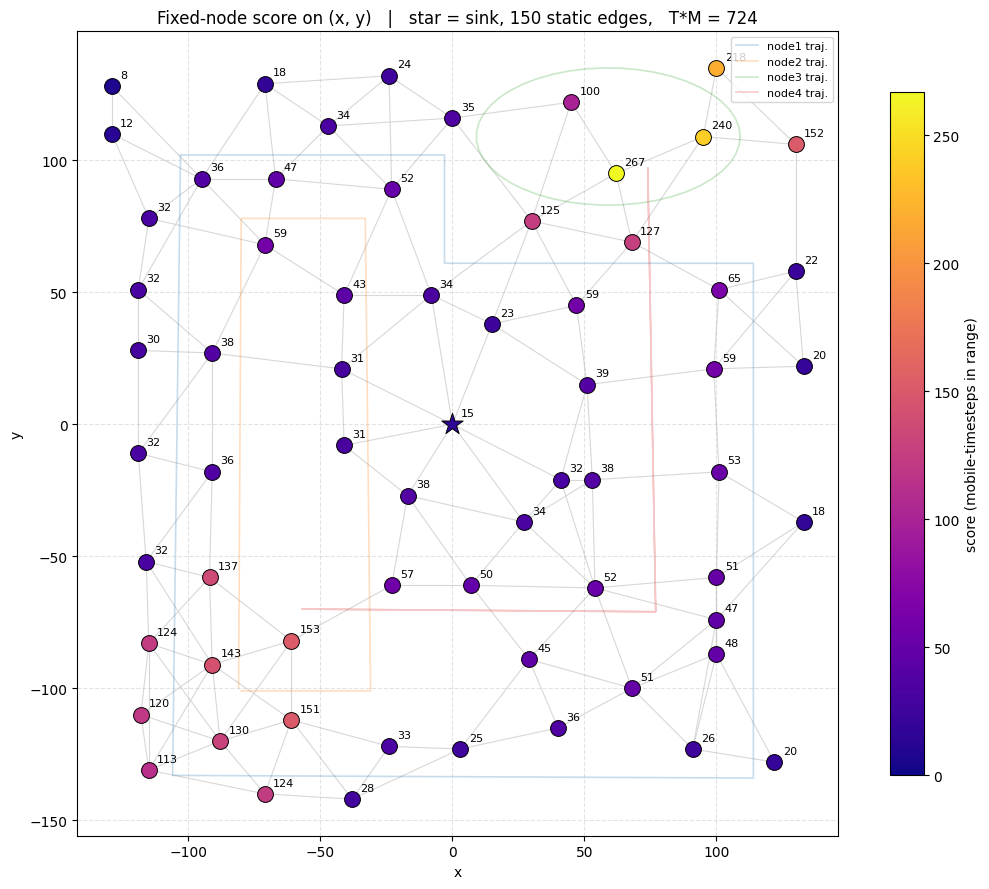

In [66]:
CMAP_NAME = "plasma"  # try "hot", "inferno", "coolwarm", "viridis", "magma"

fixed_xy = positions[0, fixed_idx]              # (1+N, 2) — sink and candidates are static
score_max = max(int(scores.max()), 1)
cmap = plt.get_cmap(CMAP_NAME)
norm = plt.Normalize(vmin=0, vmax=score_max)

# Static edges between fixed nodes: pair always within R <=> A_total[u, v] == T
fixed_block = accumulated[np.ix_(fixed_idx, fixed_idx)]
edge_us, edge_vs = np.where(np.triu(fixed_block == T, k=1))

fig, ax = plt.subplots(figsize=(11, 9))
# Edges of the static reachability graph
for u, v in zip(edge_us, edge_vs):
    ax.plot([fixed_xy[u, 0], fixed_xy[v, 0]],
            [fixed_xy[u, 1], fixed_xy[v, 1]],
            color="lightgray", linewidth=0.8, alpha=0.9, zorder=1)

# Mobile trajectories as faint context
for i in range(M):
    traj = positions[:, m_idx[i], :]
    ax.plot(traj[:, 0], traj[:, 1], color=f"C{i}", alpha=0.25,
            linewidth=1.2, zorder=1, label=f"{instance.mobile_nodes[i].name} traj.")

# Fixed nodes coloured by score
for k, gi in enumerate(fixed_idx):
    x, y = fixed_xy[k]
    s = int(scores[k])
    is_sink = (gi == s_idx)
    ax.scatter([x], [y],
               s=260 if is_sink else 130,
               marker="*" if is_sink else "o",
               c=[cmap(norm(s))],
               edgecolor="black", linewidth=0.7, zorder=3)
    ax.annotate(str(s), xy=(x, y), xytext=(6, 6),
                textcoords="offset points", fontsize=8,
                color="black", zorder=4)

ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(
    f"Fixed-node score on (x, y)   |   star = sink, "
    f"{len(edge_us)} static edges,   T*M = {T * M}"
)
ax.legend(loc="upper right", fontsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85)
cbar.set_label("score (mobile-timesteps in range)")

plt.tight_layout()
plt.show()

## Persist the result to disk (optional)

Outputs follow the existing `pop-estimator/results/` convention (one
directory per run, `.npy` matrices, `summary.json`).

In [67]:
# Uncomment to export:
# written = ab.export_results(
#     "pop-estimator/results/p3_adjacency_demo",
#     result, summary, force=True,
# )
# for k, p in written.items():
#     print(f"{k:12s} -> {p}")